# Construct the global ERA5 + SCOTIA forcing dataset

This notebook is the complete, upstream construction of the forcing dataset required by `GlobalRossbyModel`. It intentionally imports nothing from the legacy `atlantic_adjustment` package. The few physical helpers used by the old `global_atlantic_transport.ipynb` calculation are reproduced below.

The exported dataset contains exactly:

- `M_Ek_x(time, latitude, longitude)`, positive eastward, in $\mathrm{m^2\,s^{-1}}$;
- `M_Ek_y(time, latitude, longitude)`, positive northward, in $\mathrm{m^2\,s^{-1}}$; and
- `T_N(time)`, the total SCOTIA transport anomaly at the northern Atlantic boundary, positive northward, in $\mathrm{m^3\,s^{-1}}$.

ERA5 wind-stress anomalies are tapered smoothly to zero at every solid sidewall. The closed northern ends of the Indian and Pacific basins receive the same smooth meridional taper. The open Atlantic northern boundary and the open southern boundary are not tapered: `T_N` is prescribed at the former, and the model derives its southern transport from `M_Ek_y` at the latter.

Equatorial regularization follows the capped-wave-speed construction. With $f=2\Omega\sin\phi$, the inverse Coriolis factor is replaced by

$$I_\gamma(\phi)=\frac{f}{f^2+\gamma^2},$$

where $\gamma=f(\phi_c)$ and $\phi_c$ is the latitude at which $\beta g'H/f^2=\sqrt{g'H}/3$. Reference density and this regularization are recorded as provenance because both are upstream choices, outside the model package.

The native $0.25^\circ$ ERA5 grid is retained. The resulting NetCDF is deliberately written beneath `data/untracked/forcing/`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("KMP_WARNINGS", "0")

import dask
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
import xarray as xr

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = REPO_ROOT / "data" / "untracked"
ISOBATH_PATH = REPO_ROOT / "data" / "tracked" / "isobath" / "global_isobath_GEBCO_1000m.nc"
WINDS_PATH = DATA_ROOT / "ERA5" / "global_winds.nc"
SCOTIA_PATH = DATA_ROOT / "SCOTIA" / "SCOTIA_overturning_diagnostics.nc"
OUTPUT_PATH = DATA_ROOT / "forcing" / "global_ERA5_SCOTIA_forcing.nc"

for path in (ISOBATH_PATH, WINDS_PATH, SCOTIA_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required input does not exist: {path}")

print(f"Repository: {REPO_ROOT}")
print(f"Output:     {OUTPUT_PATH}")

Repository: /Users/awatford/Documents/GitHub/MOCAdjustmentTheory
Output:     /Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc


## Physical and numerical choices

`TAPER_K = 0.5 degree^-1` gives the same two-degree transition used by the legacy calculation. The wind grid is unwrapped to continuous longitudes from $-80^\circ$ to $290^\circ$, which brackets every active boundary in the 1000 m geometry.

In [2]:
EARTH_ROTATION_RATE = 7.292115e-5  # rad s-1
EARTH_RADIUS = 6.371e6             # m
RHO_0 = 1027.0                     # kg m-3; upstream conversion choice
G_PRIME = 0.02                     # m s-2; sets the capped wave speed
ATLANTIC_NORTH = 55.0              # degrees north
TAPER_K = 0.5                      # degree-1; two-degree smooth transition
ERA5_WRAP_START = 280.0            # 280..360 becomes -80..0
ERA5_EAST_LIMIT = 290.0


def coriolis(latitude):
    """Coriolis parameter in inverse seconds."""
    return 2.0 * EARTH_ROTATION_RATE * np.sin(np.deg2rad(latitude))


def beta(latitude):
    """Meridional Coriolis gradient in inverse metres per second."""
    return (
        2.0
        * EARTH_ROTATION_RATE
        * np.cos(np.deg2rad(latitude))
        / EARTH_RADIUS
    )


def cap_latitude(g_prime, depth):
    """Latitude where the long Rossby speed reaches its gravity-wave cap."""
    gravity_wave_cap = np.sqrt(g_prime * depth) / 3.0
    return float(
        optimize.brentq(
            lambda latitude: (
                beta(latitude) * g_prime * depth / coriolis(latitude) ** 2
                - gravity_wave_cap
            ),
            1.0,
            30.0,
        )
    )


def smooth_ramp(scaled_distance):
    """C-infinity ramp: zero at distance <= 0 and one at distance >= 1."""
    scaled_distance = np.asarray(scaled_distance, dtype=float)
    result = np.zeros_like(scaled_distance)
    result[scaled_distance >= 1.0] = 1.0
    transition = (scaled_distance > 0.0) & (scaled_distance < 1.0)
    left = np.exp(-1.0 / scaled_distance[transition])
    right = np.exp(-1.0 / (1.0 - scaled_distance[transition]))
    result[transition] = left / (left + right)
    return result


def zonal_taper(longitude, west, east, k=TAPER_K):
    """Legacy smooth taper between row-dependent west and east walls."""
    longitude = np.asarray(longitude, dtype=float)
    west = np.asarray(west, dtype=float)
    east = np.asarray(east, dtype=float)
    return (
        smooth_ramp(k * (longitude[None, :] - west[:, None]))
        * smooth_ramp(k * (east[:, None] - longitude[None, :]))
    )


def northern_taper(latitude, north, k=TAPER_K):
    """Smoothly reduce stress to zero at a closed northern boundary."""
    return smooth_ramp(k * (north - np.asarray(latitude, dtype=float)))


def common_latitude_domain(dataset, *boundary_names):
    """Latitude interval on which every named boundary is finite."""
    valid = [dataset[name].dropna("latitude") for name in boundary_names]
    south = max(float(boundary.latitude[0]) for boundary in valid)
    north = min(float(boundary.latitude[-1]) for boundary in valid)
    if south >= north:
        raise ValueError(f"No common domain for {boundary_names}")
    return south, north


def make_piece_taper(isobath, latitude, longitude, west_name, east_name):
    """Evaluate one basin/transition sidewall taper on selected rows."""
    boundary = isobath[[west_name, east_name]].interp(latitude=latitude)
    if bool(boundary.to_array().isnull().any()):
        raise ValueError(f"Undefined {west_name}/{east_name} boundary row")
    values = zonal_taper(
        longitude,
        boundary[west_name].values,
        boundary[east_name].values,
    )
    return xr.DataArray(
        values.astype(np.float32),
        dims=("latitude", "longitude"),
        coords={"latitude": latitude, "longitude": longitude},
    )

## Geometry and active latitude ranges

The five-region topology is represented on each latitude by one or more disjoint ocean intervals. South of the Pacific entrance there is one Atlantic-to-Pacific interval; between the Pacific and Indian entrances there is an Atlantic-to-Indian interval plus the Pacific; farther north there are separate Atlantic, Indian, and Pacific intervals.

In [3]:
isobath = xr.open_dataset(ISOBATH_PATH).dropna("latitude", how="all")
required_boundaries = {"x_wP", "x_wA", "x_wI", "x_eP", "x_eA", "x_eI"}
if set(isobath.data_vars) != required_boundaries:
    raise ValueError("Isobath dataset does not match the six-variable specification")

H = float(isobath.attrs["isobath_depth_m"])
y_S, _ = common_latitude_domain(isobath, "x_wA", "x_eP")
y_I, y_NI = common_latitude_domain(isobath, "x_wI", "x_eI")
y_P, y_NP = common_latitude_domain(isobath, "x_wP", "x_eP")
y_P = max(y_P, y_S)
_, y_NA_supported = common_latitude_domain(isobath, "x_wA", "x_eA")
if ATLANTIC_NORTH > y_NA_supported:
    raise ValueError("Atlantic geometry ends south of the northern boundary")
global_north = max(ATLANTIC_NORTH, y_NI, y_NP)

phi_c = cap_latitude(G_PRIME, H)
gamma = float(coriolis(phi_c))
print(
    f"domain: {y_S:.3f} to {ATLANTIC_NORTH:.3f} deg; "
    f"Pacific entrance {y_P:.3f} deg; Indian entrance {y_I:.3f} deg; "
    f"Pacific/Indian north {y_NP:.3f}/{y_NI:.3f} deg"
)
print(f"H={H:g} m; cap latitude={phi_c:.3f} deg; gamma={gamma:.6e} s-1")

domain: -55.075 to 55.000 deg; Pacific entrance -43.992 deg; Indian entrance -34.992 deg; Pacific/Indian north 59.358/24.658 deg
H=1000 m; cap latitude=6.877 deg; gamma=1.746177e-05 s-1


## Common monthly anomalies

SCOTIA timestamps are shifted from the monthly midpoint to the first day, matching ERA5 after its six-hour timestamp correction. Means are removed over their exact common record before any physical conversion.

In [4]:
scotia = xr.open_dataset(SCOTIA_PATH, chunks={}).moc
scotia = scotia.assign_coords(time=scotia.time - np.timedelta64(14, "D"))
scotia = scotia.astype(np.float64)
scotia_anomaly = scotia - scotia.mean("time")

winds_raw = xr.open_dataset(WINDS_PATH, chunks={})[["avg_iews", "avg_inss"]]
winds_raw = winds_raw.drop_vars(["expver", "number"], errors="ignore")
winds_raw = winds_raw.assign_coords(
    valid_time=winds_raw.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")

winds = xr.concat(
    [
        winds_raw.sel(longitude=slice(ERA5_WRAP_START, None)).assign_coords(
            longitude=lambda dataset: dataset.longitude - 360.0
        ),
        winds_raw.sel(longitude=slice(0.0, ERA5_EAST_LIMIT)),
    ],
    dim="longitude",
).sortby("longitude")
winds = winds.sel(latitude=slice(global_north, y_S)).sortby("latitude")
winds = winds.sel(time=scotia.time)
if not winds.time.equals(scotia.time):
    raise ValueError("ERA5 and SCOTIA do not share an exact monthly time grid")
winds = winds.chunk({"time": -1, "latitude": 32, "longitude": 128})
winds_anomaly = winds - winds.mean("time")

latitude = winds.latitude.values.astype(float)
longitude = winds.longitude.values.astype(float)
print(winds_anomaly.sizes)

Frozen({'latitude': 458, 'time': 246, 'longitude': 1481})


## Smooth solid-boundary taper

Each topological interval is tapered independently at its western and eastern solid walls. Taking the maximum of the interval tapers forms the single physical wind field without double-counting where extracted boundary traces touch. Indian and Pacific pieces are additionally tapered to zero at their closed northern rows. Internal gateway and open external boundaries are left unconstrained.

In [5]:
def rows(south, north, *, include_north=True):
    upper = latitude <= north if include_north else latitude < north
    return latitude[(latitude >= south) & upper]


lat_5 = rows(y_S, y_P, include_north=False)
lat_4 = rows(y_P, y_I, include_north=False)
lat_A = rows(y_I, ATLANTIC_NORTH)
lat_I = rows(y_I, y_NI)
lat_P = rows(y_P, y_NP)
if min(map(len, (lat_5, lat_4, lat_A, lat_I, lat_P))) < 2:
    raise ValueError("At least one model interval has insufficient ERA5 rows")

taper_5 = make_piece_taper(isobath, lat_5, longitude, "x_wA", "x_eP")
taper_4 = make_piece_taper(isobath, lat_4, longitude, "x_wA", "x_eI")
taper_A = make_piece_taper(isobath, lat_A, longitude, "x_wA", "x_eA")
taper_I = make_piece_taper(isobath, lat_I, longitude, "x_wI", "x_eI")
taper_P = make_piece_taper(isobath, lat_P, longitude, "x_wP", "x_eP")

y_NI_grid = float(lat_I[-1])
y_NP_grid = float(lat_P[-1])
taper_I = taper_I * xr.DataArray(
    northern_taper(lat_I, y_NI_grid), dims="latitude", coords={"latitude": lat_I}
)
taper_P = taper_P * xr.DataArray(
    northern_taper(lat_P, y_NP_grid), dims="latitude", coords={"latitude": lat_P}
)
if not np.isclose(float(taper_I.isel(latitude=-1).max()), 0.0):
    raise AssertionError("Indian northern taper does not close")
if not np.isclose(float(taper_P.isel(latitude=-1).max()), 0.0):
    raise AssertionError("Pacific northern taper does not close")

pieces = [taper_5, taper_4, taper_A, taper_I, taper_P]
solid_boundary_taper = xr.concat(
    [piece.reindex(latitude=latitude, fill_value=0.0) for piece in pieces],
    dim=xr.IndexVariable("piece", ["region_5", "region_4", "atlantic", "indian", "pacific"]),
).max("piece").fillna(0.0).astype(np.float32)
solid_boundary_taper.name = "solid_boundary_taper"
solid_boundary_taper.attrs.update(
    long_name="smooth taper applied to wind stress at solid boundaries",
    taper_k_per_degree=TAPER_K,
)
if float(solid_boundary_taper.min()) < 0.0 or float(solid_boundary_taper.max()) > 1.0:
    raise AssertionError("Taper must remain within [0, 1]")
solid_boundary_taper

<xarray.DataArray 'solid_boundary_taper' (latitude: 458, longitude: 1481)> Size: 3MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(458, 1481), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 58.75 59.0 59.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Attributes:
    long_name:           smooth taper applied to wind stress at solid boundaries
    taper_k_per_degree:  0.5

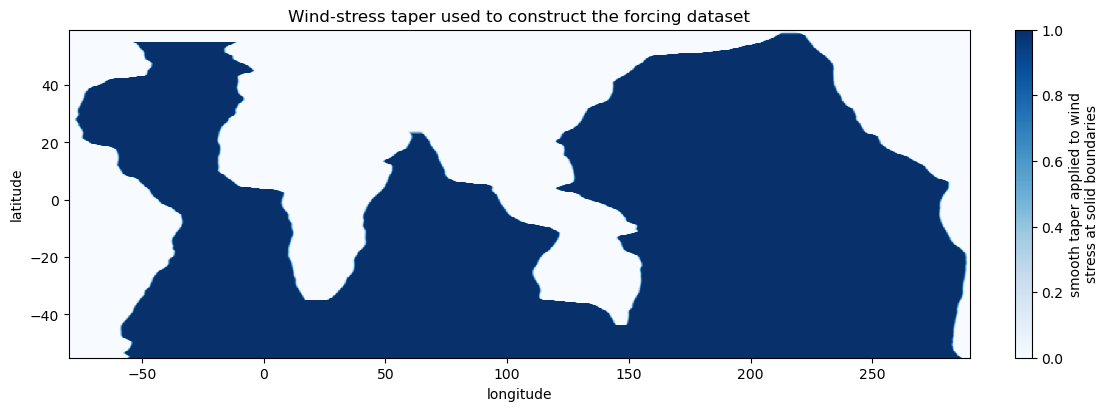

In [6]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
solid_boundary_taper.plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", cmap="Blues", vmin=0.0, vmax=1.0
)
ax.set_title("Wind-stress taper used to construct the forcing dataset")
plt.show()

## Convert tapered stress to vector Ekman transport

The taper is applied to the stress, before conversion. With eastward stress $\tau_x$ and northward stress $\tau_y$,

$$M_{\mathrm{Ek},x}=\frac{I_\gamma\tau_y}{\rho_0},\qquad M_{\mathrm{Ek},y}=-\frac{I_\gamma\tau_x}{\rho_0}.$$

The model can therefore derive both $w_{\mathrm{Ek}}=\nabla\cdot\mathbf M_{\mathrm{Ek}}$ and every Ekman section transport from the same two fields.

In [7]:
inverse_f = coriolis(winds_anomaly.latitude) / (
    coriolis(winds_anomaly.latitude) ** 2 + gamma**2
)
tau_x = winds_anomaly.avg_iews * solid_boundary_taper
tau_y = winds_anomaly.avg_inss * solid_boundary_taper

M_Ek_x_raw = tau_y * inverse_f / RHO_0
M_Ek_y_raw = -tau_x * inverse_f / RHO_0
M_Ek_x = (M_Ek_x_raw - M_Ek_x_raw.mean("time")).astype(np.float32).rename("M_Ek_x")
M_Ek_y = (M_Ek_y_raw - M_Ek_y_raw.mean("time")).astype(np.float32).rename("M_Ek_y")
T_N = (scotia_anomaly * 1e6).astype(np.float64).rename("T_N")

M_Ek_x.attrs = {
    "units": "m2 s-1",
    "long_name": "eastward Ekman transport anomaly",
    "positive": "eastward",
}
M_Ek_y.attrs = {
    "units": "m2 s-1",
    "long_name": "northward Ekman transport anomaly",
    "positive": "northward",
}
T_N.attrs = {
    "units": "m3 s-1",
    "long_name": "total northern Atlantic transport anomaly from SCOTIA",
    "positive": "northward",
}

forcing = xr.Dataset({"M_Ek_x": M_Ek_x, "M_Ek_y": M_Ek_y, "T_N": T_N})
forcing = forcing.transpose("time", "latitude", "longitude", missing_dims="ignore")
forcing.attrs.update(
    title="Global ERA5 Ekman transport and SCOTIA northern forcing anomalies",
    source_wind_stress="ERA5 monthly mean eastward/northward turbulent surface stress",
    source_northern_transport="SCOTIA overturning diagnostics MOC",
    source_geometry=ISOBATH_PATH.name,
    anomaly_reference="time mean over the common 2004-01 to 2024-06 monthly record",
    rho_0_kg_m3=RHO_0,
    g_prime_m_s2=G_PRIME,
    active_layer_depth_m=H,
    equatorial_cap_latitude_degrees=phi_c,
    equatorial_gamma_s_1=gamma,
    taper_k_per_degree=TAPER_K,
    taper_description="smooth stress taper at solid sidewalls and closed Indian/Pacific northern boundaries",
    generated_by="notebooks/construct_forcing_dataset.ipynb",
)
forcing

<xarray.Dataset> Size: 1GB
Dimensions:    (latitude: 458, time: 246, longitude: 1481)
Coordinates:
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 58.75 59.0 59.25
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 667MB dask.array<chunksize=(246, 32, 128), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 667MB dask.array<chunksize=(246, 32, 128), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/13)
    title:                            Global ERA5 Ekman transport and SCOTIA ...
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA overturning diagnostics MOC
    source_geometry:                  global_isobath_GEBCO_1000m.nc
    anomaly_reference:                time mean over the common 2004-01 to 20...
    rho_0_kg_m3:                      1027.0
    ...                               ...
    active_layer_depth_m:             1000.0
    equatorial_cap_latitude_degrees:  6.876550269787968
    equatorial_gamma_s_1:             1.7461774128542137e-05
    taper_k_per_degree:               0.5
    taper_description:                smooth stress taper at solid sidewalls ...
    generated_by:                     notebooks/construct_forcing_dataset.ipynb

## Contract checks and export

These checks are intentionally independent of the model package. They verify the three-variable schema, common time coordinate, dimensions, units, coordinate ordering, finite source values, exact zeros outside the active tapered domain, and zero-mean northern anomaly.

In [8]:
if set(forcing.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
    raise AssertionError("Forcing dataset must contain exactly three variables")
for name in ("M_Ek_x", "M_Ek_y"):
    if forcing[name].dims != ("time", "latitude", "longitude"):
        raise AssertionError(f"Unexpected dimensions for {name}")
    if forcing[name].attrs["units"] != "m2 s-1":
        raise AssertionError(f"Unexpected units for {name}")
if forcing.T_N.dims != ("time",) or forcing.T_N.attrs["units"] != "m3 s-1":
    raise AssertionError("Unexpected T_N contract")
if not forcing.time.equals(scotia.time):
    raise AssertionError("Forcing variables do not use the SCOTIA time grid")
if not np.all(np.diff(forcing.latitude) > 0) or not np.all(np.diff(forcing.longitude) > 0):
    raise AssertionError("Spatial coordinates must be strictly increasing")
if not np.isclose(float(forcing.T_N.mean()), 0.0, atol=1e-8):
    raise AssertionError("T_N is not a zero-mean anomaly")
M_Ek_time_means = dask.compute(
    abs(forcing.M_Ek_x.astype(np.float64).mean("time")).max(),
    abs(forcing.M_Ek_y.astype(np.float64).mean("time")).max(),
)
if max(map(float, M_Ek_time_means)) >= 1e-7:
    raise AssertionError(f"M_Ek anomaly mean is too large: {M_Ek_time_means}")

outside = solid_boundary_taper == 0.0
outside_sample = forcing[["M_Ek_x", "M_Ek_y"]].isel(time=[0, -1]).where(outside, 0.0)
if any(float(abs(outside_sample[name]).max().compute()) != 0.0 for name in outside_sample):
    raise AssertionError("Ekman transport is non-zero outside the tapered domain")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
temporary_path = OUTPUT_PATH.with_name(f"{OUTPUT_PATH.stem}.tmp{OUTPUT_PATH.suffix}")
if temporary_path.exists():
    temporary_path.unlink()

n_time = forcing.sizes["time"]
encoding = {
    "M_Ek_x": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "M_Ek_y": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "T_N": {"dtype": "float64", "_FillValue": None},
}
write = forcing.to_netcdf(
    temporary_path, engine="h5netcdf", encoding=encoding, compute=False
)
with dask.config.set(scheduler="threads", num_workers=4), ProgressBar():
    write.compute()
temporary_path.replace(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size / 1e9:.2f} GB)")

[                                        ] | 0% Completed | 87.92 us

[                                        ] | 1% Completed | 197.68 ms

[#                                       ] | 2% Completed | 298.06 ms

[#                                       ] | 3% Completed | 398.80 ms

[##                                      ] | 5% Completed | 502.59 ms

...

[######################################  ] | 96% Completed | 14.97 s

[####################################### ] | 97% Completed | 15.07 s

[####################################### ] | 99% Completed | 15.17 s

[########################################] | 100% Completed | 15.27 s

Wrote /Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc (0.63 GB)


In [9]:
with xr.open_dataset(OUTPUT_PATH, engine="h5netcdf", chunks={}) as exported:
    if set(exported.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
        raise AssertionError("Exported file has the wrong variables")
    if exported.sizes != forcing.sizes:
        raise AssertionError("Exported file has the wrong dimensions")
    sample = exported[["M_Ek_x", "M_Ek_y", "T_N"]].isel(
        time=[0, -1], latitude=[0, exported.sizes["latitude"] // 2, -1], longitude=[0, exported.sizes["longitude"] // 2, -1], missing_dims="ignore"
    ).load()
    if bool(sample.to_array().isnull().any()):
        raise AssertionError("Exported sample contains missing values")
    print(exported)
    print("schema and finite-value sample verified")

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 458, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 58.75 59.0 59.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 667MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 667MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/13)
    title:                            Global ERA5 Ekman transport and SCOTIA ...
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA overturning diagnostics MOC
    source_geometry:                  global_isobath_GEBCO_1000m.nc
    anomaly_reference:   